<a href="https://colab.research.google.com/github/Laban0497/FashionMNIST-ANN/blob/main/FashionClothes_ANN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

# Download / load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


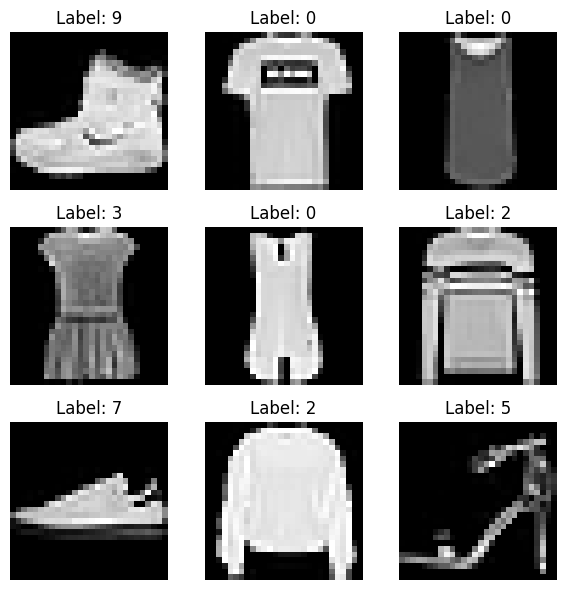

In [8]:
import matplotlib.pyplot as plt

def plot_sample_images(images, labels, num_samples=9):
    plt.figure(figsize=(6,6))
    for i in range(num_samples):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Show 9 sample images from the training set
plot_sample_images(x_train, y_train)

In [10]:
#undersating the length of the data
print(len(x_train))
print(len(x_test))

60000
10000


In [11]:
# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Quick check
print("x_train min/max:", x_train.min(), x_train.max())
print("x_test min/max:", x_test.min(), x_test.max())

x_train min/max: 0.0 0.00392156862745098
x_test min/max: 0.0 0.00392156862745098


In [13]:
#model building
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Convert 28x28 image → 1D array of 784
    keras.layers.Dense(128, activation='relu'),  # Hidden layer with 128 neurons
    keras.layers.Dense(64, activation='relu'),   # Hidden layer with 64 neurons
    keras.layers.Dense(10, activation='softmax') # Output layer for 10 classes
])

# Show model summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Multi-class classification
    metrics=['accuracy']
)

In [17]:
# Train the model
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5810 - loss: 1.2196 - val_accuracy: 0.7709 - val_loss: 0.6296
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7852 - loss: 0.5950 - val_accuracy: 0.7966 - val_loss: 0.5665
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8099 - loss: 0.5245 - val_accuracy: 0.8162 - val_loss: 0.5130
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8304 - loss: 0.4769 - val_accuracy: 0.8295 - val_loss: 0.4818
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8389 - loss: 0.4478 - val_accuracy: 0.8288 - val_loss: 0.4773
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8461 - loss: 0.4270 - val_accuracy: 0.8383 - val_loss: 0.4535
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8549 - loss: 0.4074 - val_accuracy: 0.8415 - val_loss: 0.4398
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8569 - loss: 0.4008 -

In [18]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.8505 - loss: 0.4187

Test Accuracy: 0.8505


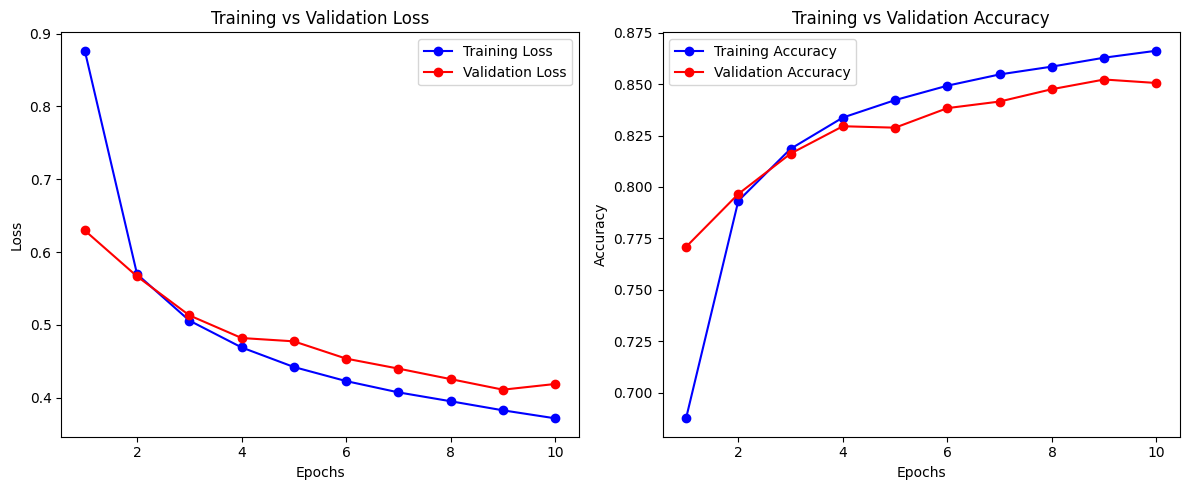

In [19]:
#visualize model's performance on the training and validation set
import matplotlib.pyplot as plt

# Extract values from training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

# Create a figure with two plots side by side
plt.figure(figsize=(12, 5))

# Plot Training & Validation Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')  # Blue line with circles
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')  # Red line with circles
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')  # Blue line
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')  # Red line
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

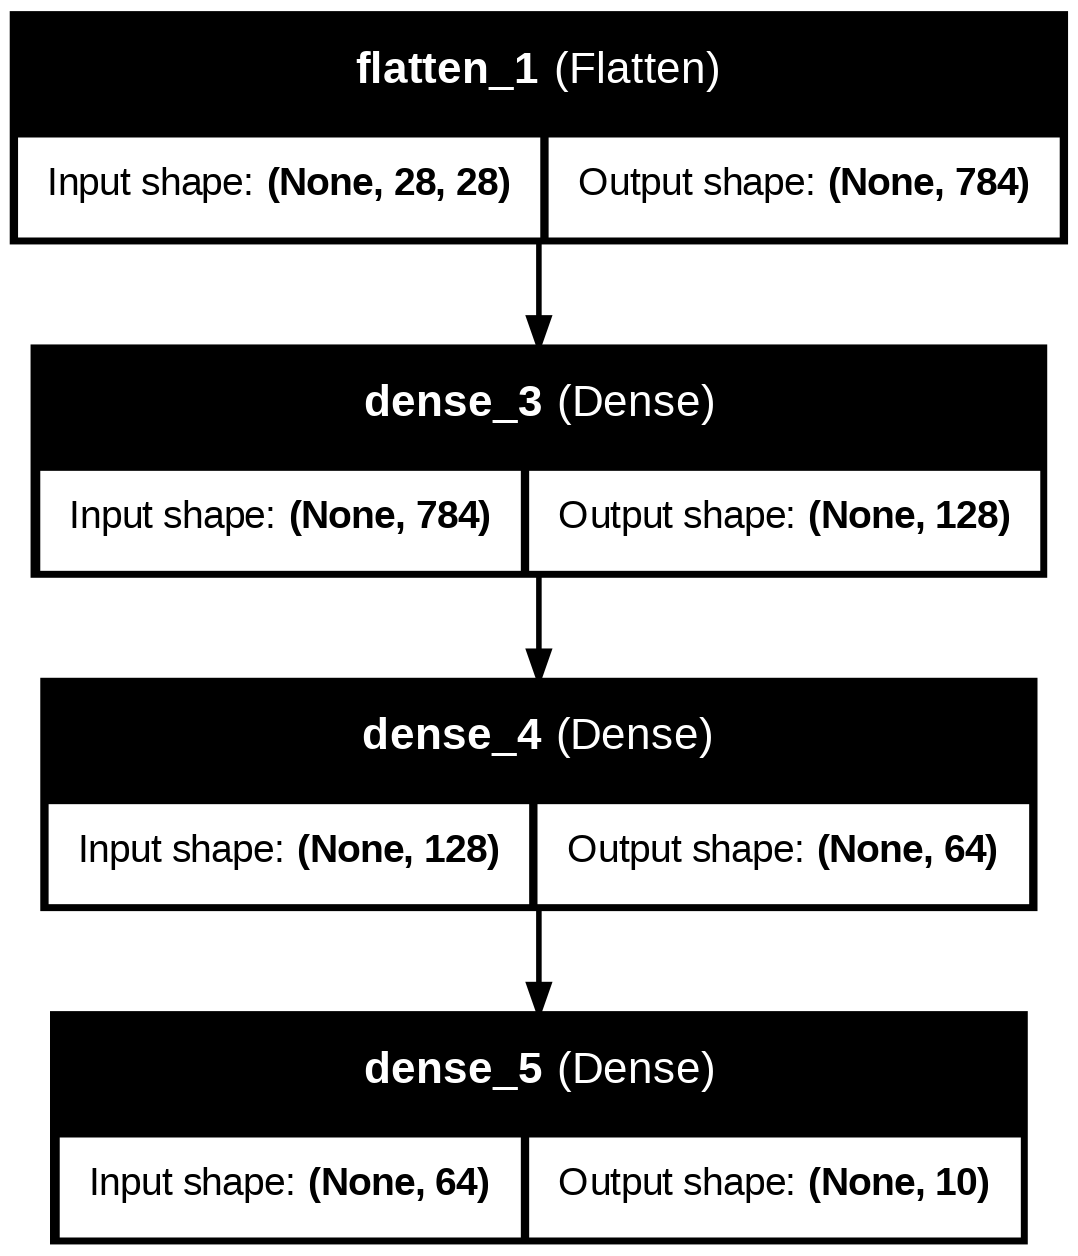

In [20]:
#Additional displays
!pip install pydot graphviz

from tensorflow.keras.utils import plot_model

# Create a visual diagram of the model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)